In [1]:
#Here I try to fit my Decision Tree to training data
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)

In [3]:
x = df.drop(columns=["ClaimNb","VehGas","VehBrand","Region"])
y = df["ClaimNb"]


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
dt = DecisionTreeRegressor(max_depth=5,min_sample_split=10,rss_loss=False)
dt.fit(x_train,y_train)


In [11]:
prediction_s = dt.predict(x_test)

In [14]:
import numpy as np
def r_squared(model,truth):
    predictions_np = np.array(model)
    true_label_np = np.array(truth)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

r_squared(prediction_s,y_test)



np.float64(2.1758215466119035e-05)

In [9]:
from sklearn.tree import DecisionTreeRegressor as SK
dt_sk = SK()
dt_sk.fit(x_train,y_train)
prediction = dt_sk.predict(x_test)

array([0., 0., 0., ..., 0., 0., 0.], shape=(108204,))

In [13]:
r_squared(prediction,y_test)

np.float64(2.1758215466119035e-05)

In [9]:
import numpy as np
def rss(data_points):
        """ For a given list of data points in a region, 
            this function returns the residual sum of squares for that region"""
        mean = np.mean(data_points)
        RSS = np.sum((data_points - mean)**2) #For each region our prediction is the mean of points in that R
        return RSS

rss(x["BonusMalus"])

np.float64(131671769.57571495)

In [40]:
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor as DecesionTree_scratch
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

def run_DT(training_data:pd.DataFrame,scratch=True):
    if scratch == True:
        dt = DecesionTree_scratch(max_depth=4,rss_loss=True)
    else: 
        dt = DecisionTreeRegressor(max_depth=4)

    Y = training_data["ClaimNb"]
    X = training_data.drop(columns="ClaimNb")
    X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
    dt.fit(X_train,Y_train)
    predictions = dt.predict(X_test)
    return predictions, Y_test

def r_squared(predictions,true_label):
    predictions_np = np.array(predictions)
    true_label_np = np.array(true_label)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

def cross_validation():
    pass



In [56]:

x = x.to_numpy()
y = y.to_numpy()
dt = DecisionTreeRegressor(max_depth=4)
dt.fit(x,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
df = pd.read_csv(r"data\claims_train_scaled.csv")
x = df.drop(columns=["ClaimNb","VehGas","VehBrand","Region","Area"])
y = df["ClaimNb"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = SK(min_samples_split=40)
dt.fit(x_train,y_train)
r_squared(dt.predict(x_test),y_test)

TypeError: BaseDecisionTree.decision_path() missing 1 required positional argument: 'X'

In [27]:
from sklearn.tree import DecisionTreeRegressor as SK
from sklearn.model_selection import KFold
df = pd.read_csv(r"data\claims_train_scaled.csv")

df = df.drop(columns=["VehGas","VehBrand","Region","Area"])
for j in range(10,100,5):
    kf = KFold(n_splits=5)
    R_Vals_sklearn = []
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        #print(f"Fold {i}:")
        df_train = df.iloc[train_index]
        df_test = df.iloc[test_index]
        dt = SK(min_samples_split=j)
        dt.fit(df_train.drop("ClaimNb",axis=1),df_train["ClaimNb"])
        predictions = dt.predict(df_test.drop("ClaimNb",axis=1))
        r = r_squared(predictions,df_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")
        

Max Depth = 10
For max samples = 10 the average R Squared Value is -0.5158669473734947
Max Depth = 15
For max samples = 15 the average R Squared Value is -0.37730558968322986
Max Depth = 20
For max samples = 20 the average R Squared Value is -0.3010059930523791
Max Depth = 25
For max samples = 25 the average R Squared Value is -0.25143767934358163
Max Depth = 30
For max samples = 30 the average R Squared Value is -0.21631495253891608
Max Depth = 35
For max samples = 35 the average R Squared Value is -0.19141303942545868
Max Depth = 40
For max samples = 40 the average R Squared Value is -0.16950485093719117
Max Depth = 45
For max samples = 45 the average R Squared Value is -0.15323428240941078
Max Depth = 50
For max samples = 50 the average R Squared Value is -0.13902547502435245
Max Depth = 55
For max samples = 55 the average R Squared Value is -0.12492830057338962
Max Depth = 60
For max samples = 60 the average R Squared Value is -0.11471894855789619
Max Depth = 65
For max samples = 6

In [21]:
R_Vals_sklearn

[np.float64(0.01708454006548034),
 np.float64(0.019721219856935385),
 np.float64(0.02003099696308602),
 np.float64(0.017947846640722277),
 np.float64(0.01998720634454142)]

In [ ]:
#using pca scores to fit DT
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
df = pd.read_csv(r"data\claims_train_scaled.csv")
df_new = df.drop(columns=["VehGas","VehBrand","Region","Area","ClaimNb"])
pca_claims = PCA()
pca_claims.fit(df_new)
scores = pca_claims.transform(df_new)
df_pca = pd.DataFrame(scores)


541016

Text(0, 0.5, 'Cummalative Sum of Explained Variance')

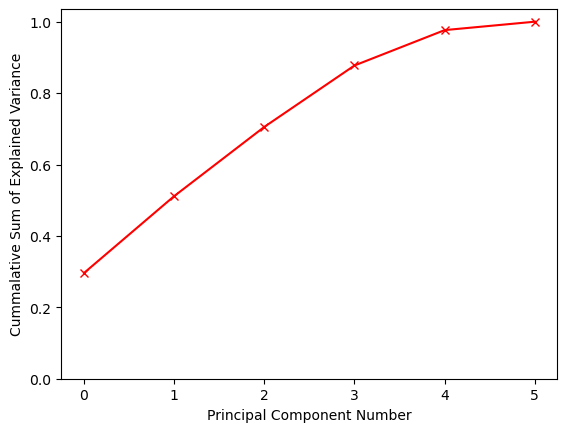

In [80]:
#explained variance
explained_var = pca_claims.explained_variance_ratio_
cum_sum = np.cumsum(explained_var)
plt.plot(range(len(cum_sum)),cum_sum,marker="x",c="red")
plt.ylim(0)
plt.xlabel("Principal Component Number")
plt.ylabel("Cummalative Sum of Explained Variance")


In [86]:
for j in range(1,5):
    kf = KFold(n_splits=5)
    R_Vals_sklearn = []
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df_pca)):
        #print(f"Fold {i}:")
        df_train = df_pca.iloc[train_index]
        df_target_train = df.iloc[train_index]
        df_test = df_pca.iloc[test_index]
        df_target_test = df.iloc[test_index]
        dt = SK(max_depth=j)
        dt.fit(df_train,df_target_train["ClaimNb"])
        predictions = dt.predict(df_test)
        r = r_squared(predictions,df_target_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")

Max Depth = 1
For max samples = 1 the average R Squared Value is 0.005021929376984748
Max Depth = 2
For max samples = 2 the average R Squared Value is 0.008213188459572238
Max Depth = 3
For max samples = 3 the average R Squared Value is 0.011126239305023902
Max Depth = 4
For max samples = 4 the average R Squared Value is 0.013737644999280197
